# 04 — Evaluasi Model
- Metrik: Accuracy, Precision, Recall, F1-Score, AUC
- Confusion Matrix (raw & normalized)
- Classification Report per kelas
- ROC-AUC Curve
- Kurva Training

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from src.config import TEST_DIR, MODEL_DIR, RESULTS_DIR, CLASSES, BATCH_SIZE, NUM_CLASSES
from src.train import get_generators
from src.utils import load_pickle

EVAL_DIR = os.path.join(RESULTS_DIR, 'evaluation')
os.makedirs(EVAL_DIR, exist_ok=True)

sns.set_theme(style='whitegrid')
print('Setup OK')

✅ Config loaded successfully!
📁 RAW_DIR: C:\Users\ACER\Documents\ANALIS CITRA.py\dataset\raw\Comprehensive Disaster Dataset(CDD)
📁 TRAIN_DIR: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\dataset\processed\train
📁 VAL_DIR: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\dataset\processed\val
📁 TEST_DIR: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\dataset\processed\test
📊 Classes: ['Damaged_Infrastructure', 'Fire_Disaster', 'Human_Damage', 'Land_Disaster', 'Non_Damage', 'Water_Disaster']
📐 Input Shape: (224, 224, 3)
🔄 FREEZE_EPOCHS: 10
🔄 FINETUNE_EPOCHS: 10
Setup OK


## 1. Load Model & Test Generator

In [2]:
model_path = '../models/final_model.keras'
model = tf.keras.models.load_model(model_path)
print(f'Model loaded: {model_path}')

_, _, test_gen = get_generators()
class_names = list(test_gen.class_indices.keys())
print(f'Kelas       : {class_names}')
print(f'Test samples: {test_gen.samples}')

Model loaded: ../models/final_model.keras
Found 9485 images belonging to 6 classes.
Found 2030 images belonging to 6 classes.
Found 2040 images belonging to 6 classes.
Kelas       : ['Damaged_Infrastructure', 'Fire_Disaster', 'Human_Damage', 'Land_Disaster', 'Non_Damage', 'Water_Disaster']
Test samples: 2040


## 2. Prediksi pada Test Set

In [3]:
test_gen.reset()
print('Prediksi...')
y_proba = model.predict(test_gen, verbose=1)   # (N, 6) probabilitas
y_pred  = np.argmax(y_proba, axis=1)           # kelas prediksi
y_true  = test_gen.classes                      # label asli

print(f'y_true shape: {y_true.shape}')
print(f'y_pred shape: {y_pred.shape}')
print(f'y_proba shape: {y_proba.shape}')

Prediksi...
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 243ms/step
y_true shape: (2040,)
y_pred shape: (2040,)
y_proba shape: (2040, 6)


## 3. Metrik Keseluruhan

In [4]:
# Hitung dari sklearn — tidak bergantung pada model.compile metrics
test_acc  = accuracy_score(y_true, y_pred)
test_prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
test_rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
test_f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

# AUC (macro OvR)
y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
auc_scores = []
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    auc_scores.append(auc(fpr, tpr))
test_auc = np.mean(auc_scores)

# Evaluasi loss dari model
test_gen.reset()
eval_results = model.evaluate(test_gen, verbose=0)
test_loss = eval_results[0]

print('=' * 50)
print('  HASIL EVALUASI MODEL')
print('=' * 50)
print(f'  Test Accuracy  : {test_acc*100:.2f}%')
print(f'  Test Precision : {test_prec*100:.2f}%  (weighted)')
print(f'  Test Recall    : {test_rec*100:.2f}%  (weighted)')
print(f'  Test F1-Score  : {test_f1*100:.2f}%  (weighted)')
print(f'  Test AUC (macro): {test_auc:.4f}')
print(f'  Test Loss      : {test_loss:.4f}')
print('=' * 50)

# Simpan ringkasan
summary = {
    'accuracy' : round(test_acc, 4),
    'precision': round(test_prec, 4),
    'recall'   : round(test_rec, 4),
    'f1_score' : round(test_f1, 4),
    'auc_macro': round(test_auc, 4),
    'loss'     : round(float(test_loss), 4),
}
import json
with open(os.path.join(EVAL_DIR, 'test_metrics.json'), 'w') as f:
    json.dump(summary, f, indent=2)
print('[saved] test_metrics.json')

  HASIL EVALUASI MODEL
  Test Accuracy  : 94.31%
  Test Precision : 94.57%  (weighted)
  Test Recall    : 94.31%  (weighted)
  Test F1-Score  : 94.25%  (weighted)
  Test AUC (macro): 0.9924
  Test Loss      : 0.2236
[saved] test_metrics.json


## 4. Confusion Matrix

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\evaluation\confusion_matrix.png


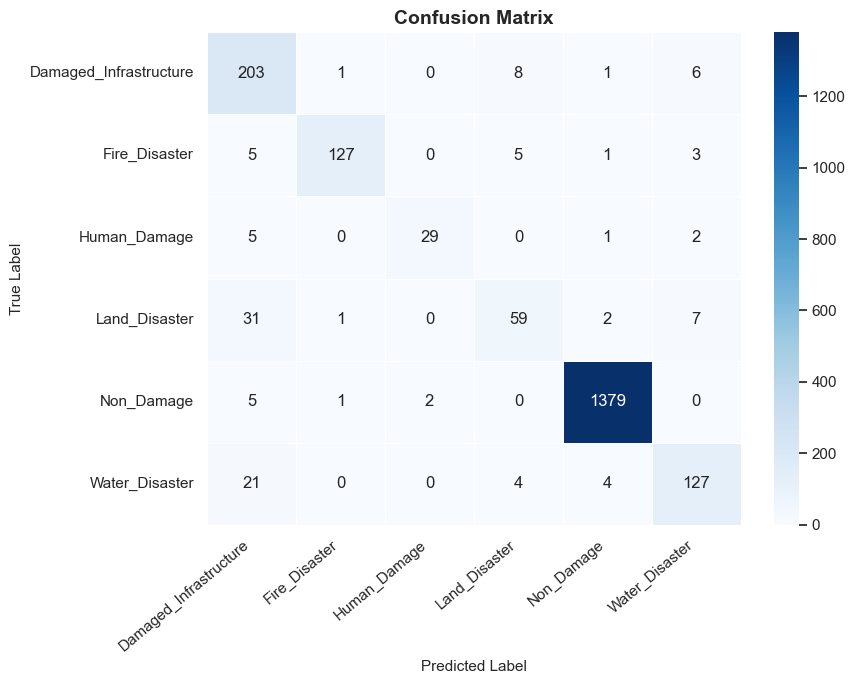

In [5]:
def plot_cm(y_true, y_pred, class_names, normalize=False, save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt, title = '.2f', 'Normalized Confusion Matrix'
    else:
        fmt, title = 'd', 'Confusion Matrix'

    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=11)
    plt.xlabel('Predicted Label', fontsize=11)
    plt.xticks(rotation=40, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f'[saved] {save_path}')
    plt.show()
    return cm

cm_raw  = plot_cm(y_true, y_pred, class_names,
                  save_path=os.path.join(EVAL_DIR, 'confusion_matrix.png'))

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\evaluation\confusion_matrix_norm.png


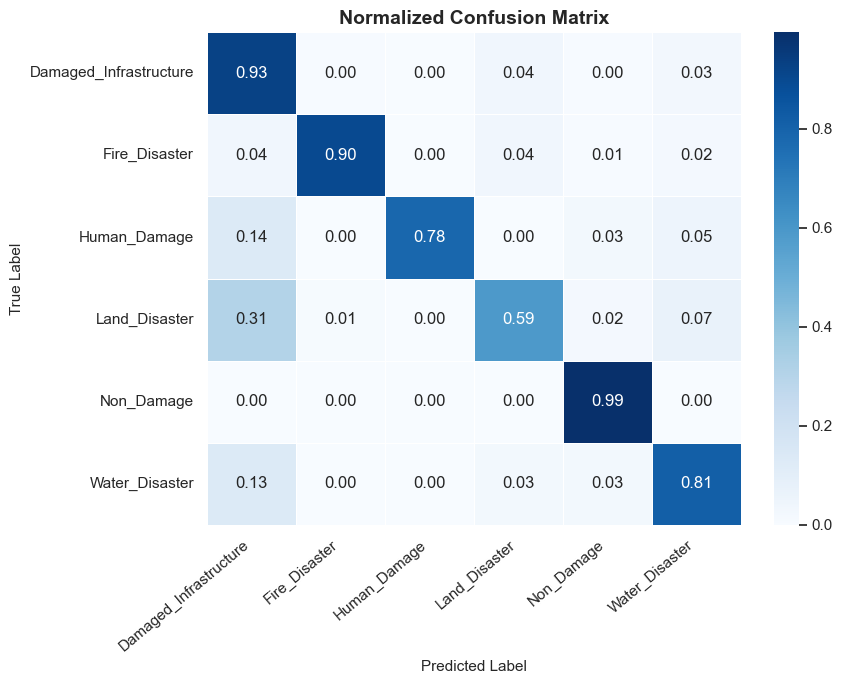

array([[9.26940639e-01, 4.56621005e-03, 0.00000000e+00, 3.65296804e-02,
        4.56621005e-03, 2.73972603e-02],
       [3.54609929e-02, 9.00709220e-01, 0.00000000e+00, 3.54609929e-02,
        7.09219858e-03, 2.12765957e-02],
       [1.35135135e-01, 0.00000000e+00, 7.83783784e-01, 0.00000000e+00,
        2.70270270e-02, 5.40540541e-02],
       [3.10000000e-01, 1.00000000e-02, 0.00000000e+00, 5.90000000e-01,
        2.00000000e-02, 7.00000000e-02],
       [3.60490267e-03, 7.20980534e-04, 1.44196107e-03, 0.00000000e+00,
        9.94232156e-01, 0.00000000e+00],
       [1.34615385e-01, 0.00000000e+00, 0.00000000e+00, 2.56410256e-02,
        2.56410256e-02, 8.14102564e-01]])

In [6]:
# Normalized
plot_cm(y_true, y_pred, class_names, normalize=True,
        save_path=os.path.join(EVAL_DIR, 'confusion_matrix_norm.png'))

## 5. Classification Report

In [7]:
report_str = classification_report(
    y_true, y_pred,
    target_names = class_names,
    digits       = 4,
)
print('=' * 60)
print('  CLASSIFICATION REPORT')
print('=' * 60)
print(report_str)

with open(os.path.join(EVAL_DIR, 'classification_report.txt'), 'w') as f:
    f.write(report_str)
print('[saved] classification_report.txt')

  CLASSIFICATION REPORT
                        precision    recall  f1-score   support

Damaged_Infrastructure     0.7519    0.9269    0.8303       219
         Fire_Disaster     0.9769    0.9007    0.9373       141
          Human_Damage     0.9355    0.7838    0.8529        37
         Land_Disaster     0.7763    0.5900    0.6705       100
            Non_Damage     0.9935    0.9942    0.9939      1387
        Water_Disaster     0.8759    0.8141    0.8439       156

              accuracy                         0.9431      2040
             macro avg     0.8850    0.8350    0.8548      2040
          weighted avg     0.9457    0.9431    0.9425      2040

[saved] classification_report.txt


## 6. Tabel Metrik per Kelas

In [8]:
rows = []
for i, cls in enumerate(class_names):
    yt = (y_true == i).astype(int)
    yp = (y_pred == i).astype(int)
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    rows.append({
        'Kelas'    : cls,
        'Support'  : int(yt.sum()),
        'Precision': round(precision_score(yt, yp, zero_division=0), 4),
        'Recall'   : round(recall_score(yt, yp, zero_division=0), 4),
        'F1-Score' : round(f1_score(yt, yp, zero_division=0), 4),
        'AUC'      : round(auc(fpr, tpr), 4),
    })

df_metrics = pd.DataFrame(rows)
print(df_metrics.to_string(index=False))

df_metrics.to_csv(os.path.join(EVAL_DIR, 'metrics_per_class.csv'), index=False)
print('\n[saved] metrics_per_class.csv')

                 Kelas  Support  Precision  Recall  F1-Score    AUC
Damaged_Infrastructure      219     0.7519  0.9269    0.8303 0.9910
         Fire_Disaster      141     0.9769  0.9007    0.9373 0.9956
          Human_Damage       37     0.9355  0.7838    0.8529 0.9978
         Land_Disaster      100     0.7763  0.5900    0.6705 0.9819
            Non_Damage     1387     0.9935  0.9942    0.9939 0.9996
        Water_Disaster      156     0.8759  0.8141    0.8439 0.9888

[saved] metrics_per_class.csv


## 7. Visualisasi Metrik per Kelas

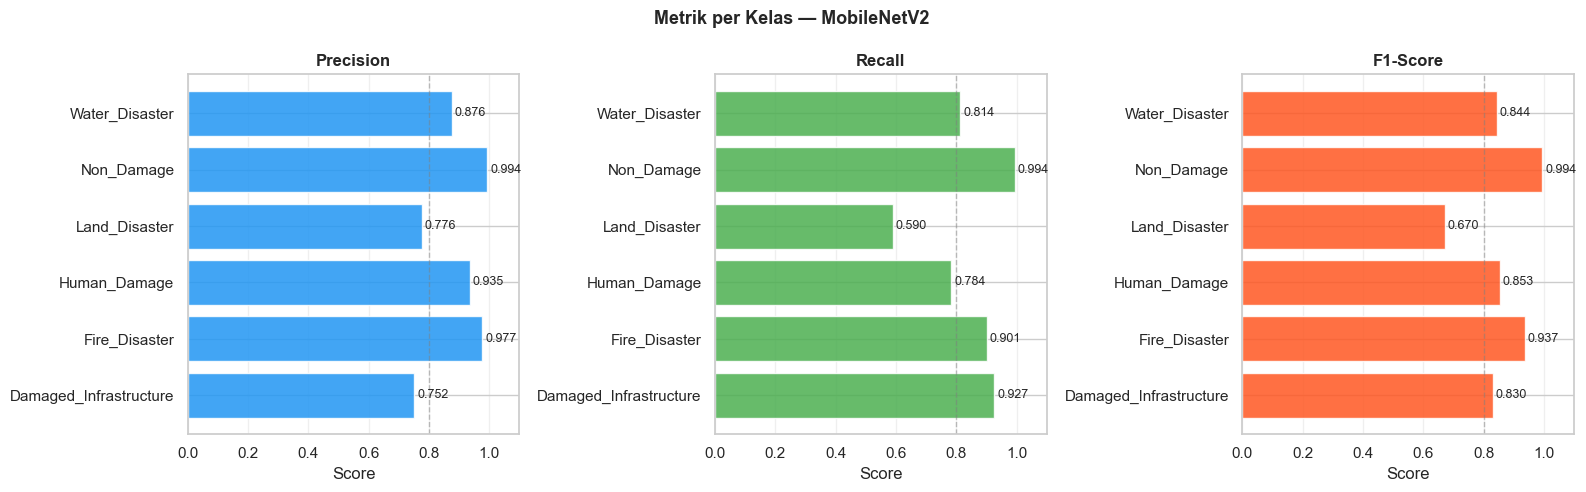

[saved] metrics_per_class.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['Precision', 'Recall', 'F1-Score']
colors  = ['#2196F3', '#4CAF50', '#FF5722']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.barh(df_metrics['Kelas'], df_metrics[metric],
                   color=color, alpha=0.85, edgecolor='white')
    ax.set_xlim(0, 1.1)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_xlabel('Score')
    ax.axvline(0.8, color='gray', ls='--', lw=1, alpha=0.5)
    for bar, val in zip(bars, df_metrics[metric]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Metrik per Kelas — MobileNetV2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'metrics_per_class.png'), dpi=150)
plt.show()
print('[saved] metrics_per_class.png')

## 8. Kurva Training

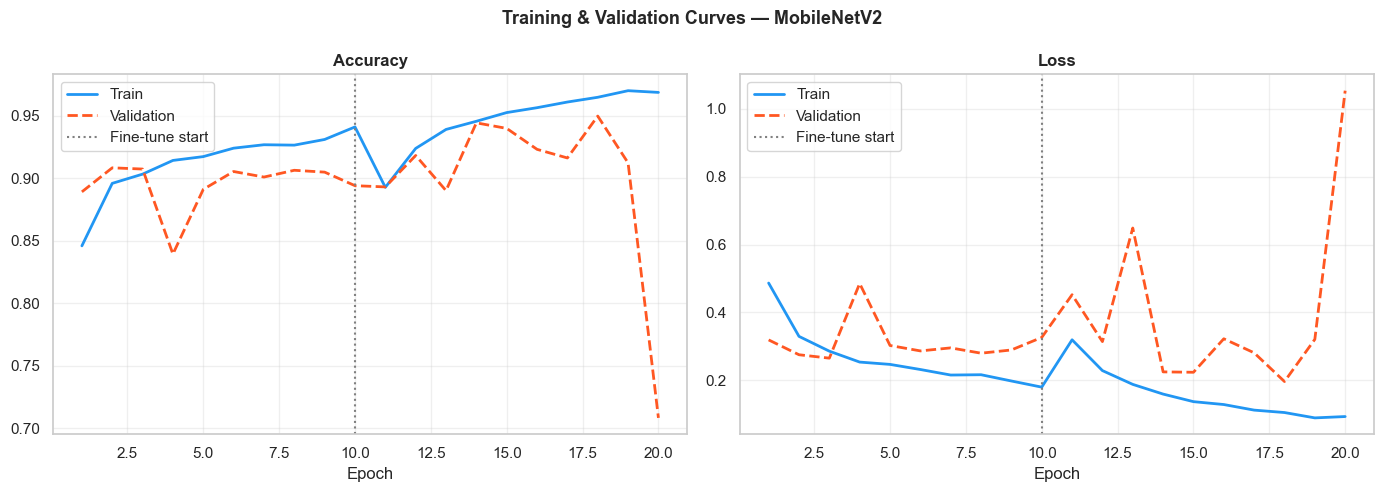

[saved] training_curves.png


In [10]:
history = load_pickle('../models/history.pkl')
epochs  = range(1, len(history['accuracy']) + 1)
freeze_end = len(load_pickle('../models/history_freeze.pkl')['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, history['accuracy'],     label='Train',      color='#2196F3', lw=2)
ax1.plot(epochs, history['val_accuracy'], label='Validation', color='#FF5722', lw=2, ls='--')
ax1.axvline(freeze_end, color='gray', ls=':', lw=1.5, label='Fine-tune start')
ax1.set_title('Accuracy', fontweight='bold'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, history['loss'],     label='Train',      color='#2196F3', lw=2)
ax2.plot(epochs, history['val_loss'], label='Validation', color='#FF5722', lw=2, ls='--')
ax2.axvline(freeze_end, color='gray', ls=':', lw=1.5, label='Fine-tune start')
ax2.set_title('Loss', fontweight='bold'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Training & Validation Curves — MobileNetV2',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'training_curves.png'), dpi=150)
plt.show()
print('[saved] training_curves.png')

## 9. ROC-AUC Curve

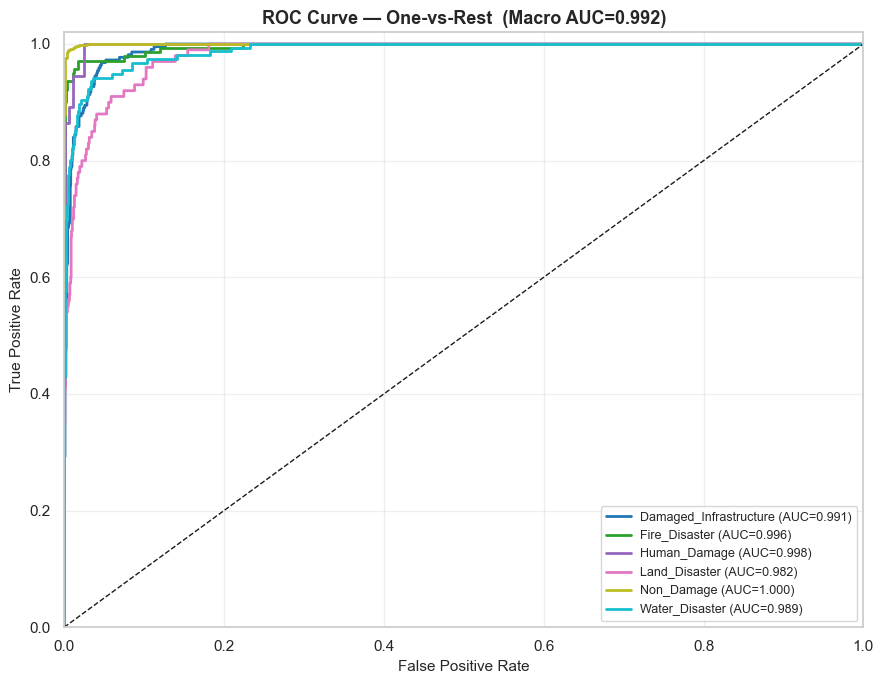

[saved] roc_curves.png


In [11]:
plt.figure(figsize=(9, 7))
colors_roc = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

for i, (cls, col) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=col, lw=2,
             label=f'{cls} (AUC={roc_auc:.3f})')

plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlim([0,1]); plt.ylim([0,1.02])
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title(f'ROC Curve — One-vs-Rest  (Macro AUC={test_auc:.3f})',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'roc_curves.png'), dpi=150)
plt.show()
print('[saved] roc_curves.png')

## 10. Ringkasan Akhir untuk Jurnal

In [12]:
print('\n' + '='*60)
print('  RINGKASAN HASIL — UNTUK JURNAL')
print('='*60)
print(f'  Model          : MobileNetV2 (Transfer Learning)')
print(f'  Dataset        : CDD ({test_gen.samples} test images, 6 kelas)')
print(f'  Test Accuracy  : {test_acc*100:.2f}%')
print(f'  Precision      : {test_prec*100:.2f}%  (weighted avg)')
print(f'  Recall         : {test_rec*100:.2f}%  (weighted avg)')
print(f'  F1-Score       : {test_f1*100:.2f}%  (weighted avg)')
print(f'  AUC (macro)    : {test_auc:.4f}')
print('='*60)
print('\nFile tersimpan di:', EVAL_DIR)
for f in os.listdir(EVAL_DIR):
    print(f'  - {f}')


  RINGKASAN HASIL — UNTUK JURNAL
  Model          : MobileNetV2 (Transfer Learning)
  Dataset        : CDD (2040 test images, 6 kelas)
  Test Accuracy  : 94.31%
  Precision      : 94.57%  (weighted avg)
  Recall         : 94.31%  (weighted avg)
  F1-Score       : 94.25%  (weighted avg)
  AUC (macro)    : 0.9924

File tersimpan di: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\evaluation
  - classification_report.txt
  - confusion_matrix.png
  - confusion_matrix_norm.png
  - metrics_per_class.csv
  - metrics_per_class.png
  - roc_curves.png
  - test_metrics.json
  - training_curves.png


---
### ✅ Evaluasi selesai. Lanjut ke `05_GradCAM.ipynb`